# Time Series Analysis & Forecasting for Multiple Humidity Sensors in a Warehouse

In [222]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pmdarima as pm

In [223]:
def adf_test_results(data):
    result = adfuller(data.dropna()) # dropna() to handle potential missing values
    return {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Critical Values': result[4],
        'is_stationary': result[1] < 0.05 # Check p-value against 0.05
    }

In [224]:
file_path = r"C:\\Users\\sulaiman.at\\Documents\\GitHub\\TSA&F-Humidity-Warehouse\\RawData1.xls"
# Load the data
data = pd.read_excel(file_path, engine="xlrd")

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


In [225]:
data.head()

,Index,Time,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%)
0,1,02/27/2025 10:04:44 AM,80.21,78.64,76.12,77.16,78.87,78.25
1,2,02/27/2025 10:04:46 AM,80.19,78.64,76.12,77.16,78.88,78.26
2,3,02/27/2025 10:04:48 AM,80.21,78.65,76.10,77.14,78.87,78.24
3,4,02/27/2025 10:04:50 AM,80.06,78.64,76.12,77.17,78.87,78.12
4,5,02/27/2025 10:04:52 AM,80.06,78.64,76.12,77.18,78.88,78.12


In [226]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 65534 entries, 0 to 65533
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Index    65534 non-null  int64  
 1   Time     65534 non-null  str    
 2   CH01(%)  65534 non-null  float64
 3   CH02(%)  65534 non-null  float64
 4   CH03(%)  65534 non-null  float64
 5   CH04(%)  65534 non-null  float64
 6   CH05(%)  65534 non-null  float64
 7   CH06(%)  65534 non-null  float64
dtypes: float64(6), int64(1), str(1)
memory usage: 4.0 MB


In [227]:

# Convert Time column from string to datetime
data['Time'] = pd.to_datetime(data['Time'], format='mixed')

# Set Time as index for time series analysis
data = data.set_index('Time')


In [228]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 65534 entries, 2025-02-27 10:04:44 to 2025-02-28 22:29:10
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Index    65534 non-null  int64  
 1   CH01(%)  65534 non-null  float64
 2   CH02(%)  65534 non-null  float64
 3   CH03(%)  65534 non-null  float64
 4   CH04(%)  65534 non-null  float64
 5   CH05(%)  65534 non-null  float64
 6   CH06(%)  65534 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 4.0 MB


In [229]:
data.index.is_monotonic_increasing

# If returns False, sort the index
# data = data.sort_index()

True

In [230]:
# Remove impossible humidity values
data = data.replace(-32640, pd.NA)

# Drop rows where all channels are missing
data = data.dropna(how='all')

In [231]:
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 65534 entries, 2025-02-27 10:04:44 to 2025-02-28 22:29:10
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Index    65534 non-null  int64  
 1   CH01(%)  65534 non-null  float64
 2   CH02(%)  65534 non-null  float64
 3   CH03(%)  65534 non-null  float64
 4   CH04(%)  65534 non-null  float64
 5   CH05(%)  65534 non-null  float64
 6   CH06(%)  65534 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 4.0 MB


In [232]:
data.head()

,Index,CH01(%),CH02(%),CH03(%),CH04(%),CH05(%),CH06(%)
Time,,,,,,,
2025-02-27 10:04:44,1,80.21,78.64,76.12,77.16,78.87,78.25
2025-02-27 10:04:46,2,80.19,78.64,76.12,77.16,78.88,78.26
2025-02-27 10:04:48,3,80.21,78.65,76.10,77.14,78.87,78.24
2025-02-27 10:04:50,4,80.06,78.64,76.12,77.17,78.87,78.12
2025-02-27 10:04:52,5,80.06,78.64,76.12,77.18,78.88,78.12


In [233]:
# Apply the function to all columns (excluding date/index if necessary)
results = {col: adf_test_results(data[col]) for col in data.columns if col != 'date_column_name'}
results_df = pd.DataFrame(results).T # Transpose for better readability
print(results_df)

        ADF Statistic   p-value  \
Index       50.853012       1.0   
CH01(%)     -0.404936  0.909271   
CH02(%)     -0.473856  0.897018   
CH03(%)     -0.640336  0.861605   
CH04(%)     -1.805174  0.377896   
CH05(%)     -0.654888  0.858091   
CH06(%)     -0.392534  0.911338   

                                           Critical Values is_stationary  
Index    {'1%': -3.4304498375055035, '5%': -2.861584126...         False  
CH01(%)  {'1%': -3.430449881728331, '5%': -2.8615841459...         False  
CH02(%)  {'1%': -3.430449878677223, '5%': -2.8615841445...         False  
CH03(%)  {'1%': -3.430449881728331, '5%': -2.8615841459...         False  
CH04(%)  {'1%': -3.4304498695250176, '5%': -2.861584140...         False  
CH05(%)  {'1%': -3.4304498802027537, '5%': -2.861584145...         False  
CH06(%)  {'1%': -3.4304498603744893, '5%': -2.861584136...         False  


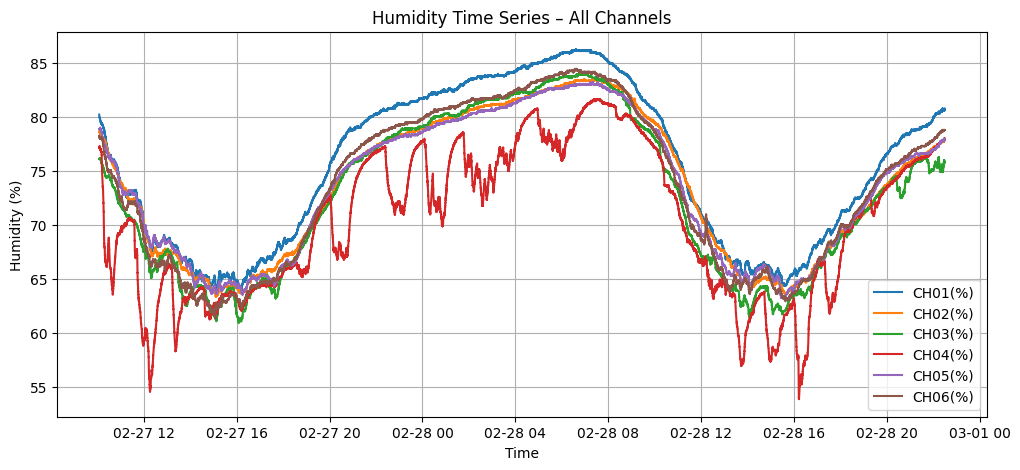

In [234]:

# Convert all columns to numeric and coerce errors to NaN (in case there are any non-numeric values)
data = data.apply(pd.to_numeric, errors='coerce')

# Drop the non-sensor column if it exists
data = data.drop(columns=['Index'], errors='ignore')

plt.figure(figsize=(12,5))
for col in data.columns:
    plt.plot(data.index, data[col], label=col)

plt.title("Humidity Time Series – All Channels")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()


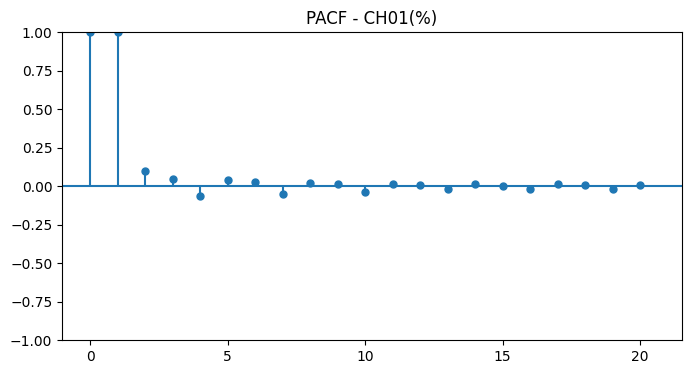

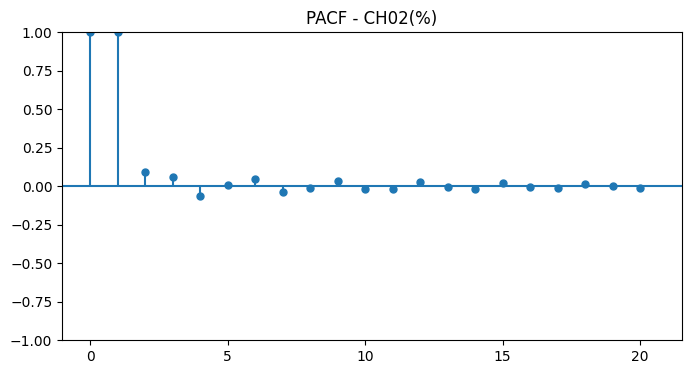

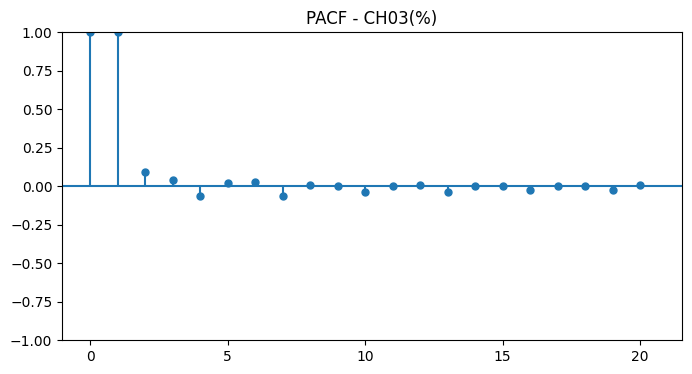

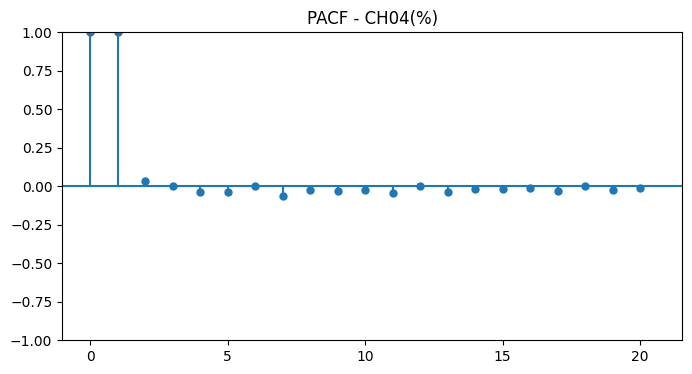

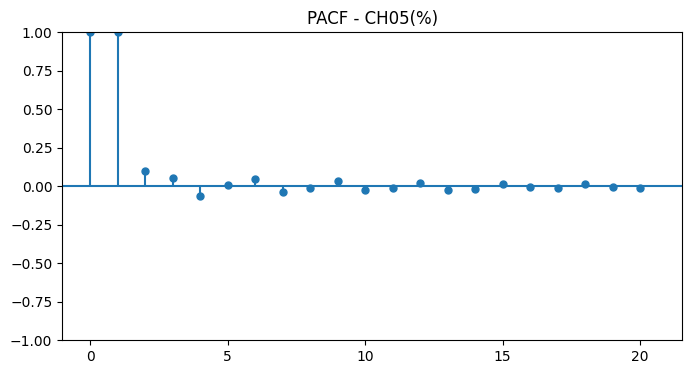

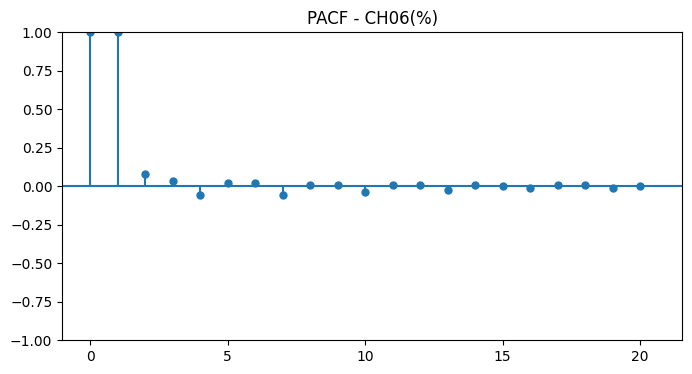

In [235]:
for column in data.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    # 'method' can be 'yw' (default) or 'ols'
    plot_pacf(data[column].dropna(), lags=20, ax=ax, title=f'PACF - {column}')
    plt.show()

In [236]:
# Choose one channel
y = data['CH04(%)'].copy()

# Ensure numeric and handle error codes
y = pd.to_numeric(y, errors='coerce').replace(-32640, np.nan)

# Sort time
y = y.sort_index()

# Align timestamps to nearest 30 minutes and aggregate duplicates
y.index = y.index.round('30min')
y = y.groupby(level=0).mean()

# Enforce strict 30-min frequency
y = y.asfreq('30min')

# Fill small gaps (safe for short-term forecasting)
y = y.interpolate('time').ffill().bfill()

# Train/test split
split = int(len(y) * 0.8)
train = y.iloc[:split]
test  = y.iloc[split:]  

In [237]:

model = pm.auto_arima(
    train,
    seasonal=False,        
    stepwise=True,
    trace=True,
    error_action="ignore",
    suppress_warnings=True
)

model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=301.398, Time=0.15 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=672.455, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=301.747, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=inf, Time=0.13 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=inf, Time=0.22 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=inf, Time=0.20 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=305.797, Time=0.04 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=inf, Time=0.14 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=295.371, Time=0.09 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.06 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=290.813, Time=0.13 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=inf, Time=0.08 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=inf, Time=0.26 sec
 ARIMA(4,0,2)(0,0,

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   59
Model:               SARIMAX(4, 0, 1)   Log Likelihood                -133.615
Date:                Mon, 30 Mar 2026   AIC                            281.229
Time:                        12:05:27   BIC                            295.772
Sample:                    02-27-2025   HQIC                           286.906
                         - 02-28-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      3.8943      1.450      2.685      0.007       1.052       6.737
ar.L1          1.5182      0.144     10.558      0.000       1.236       1.800
ar.L2         -0.8163      0.243     -3.361      0.001      -1.292      -0.340
ar.L3          0.9006      0.156      5.775      0.000       0.595       1.206
ar.L4         -0.6569      0.076     -8.645      0.000      -0.806      -0.508
ma.L1         -0.7332      0.166     -4.423      0.000      -1.058      -0.408
sigma2         5.0557      0.859      5.884      0.000       3.372       6.740
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):                 1.27
Prob(Q):                              0.87   Prob(JB):                         0.53
Heteroskedasticity (H):               0.53   Skew:                            -0.13
Prob(H) (two-sided):                  0.17   Kurtosis:                         3.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

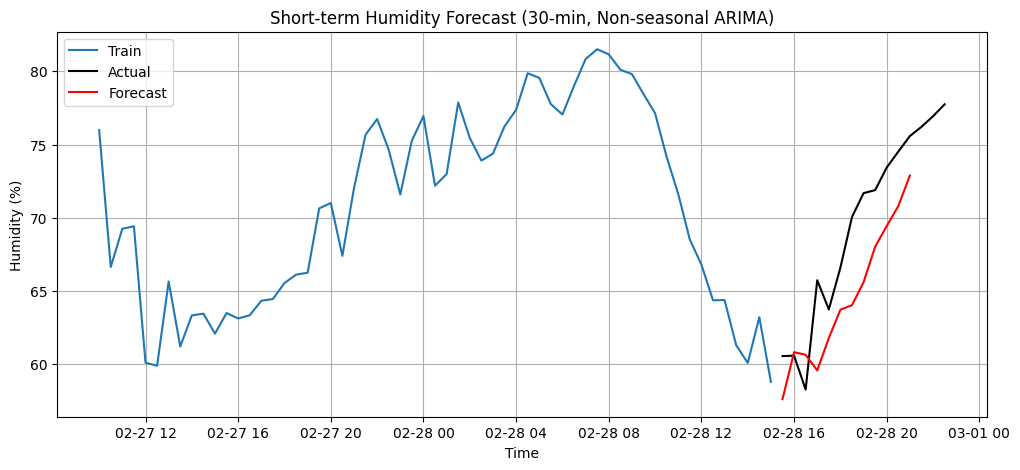

In [238]:

n_periods = 12
forecast = model.predict(n_periods=n_periods)

forecast_index = pd.date_range(start=test.index[0], periods=n_periods, freq='30min')
forecast_series = pd.Series(forecast, index=forecast_index)

plt.figure(figsize=(12,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Actual", color="black")
plt.plot(forecast_series.index, forecast_series, label="Forecast", color="red")
plt.title("Short-term Humidity Forecast (30-min, Non-seasonal ARIMA)")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.grid(True)
plt.legend()
plt.show()


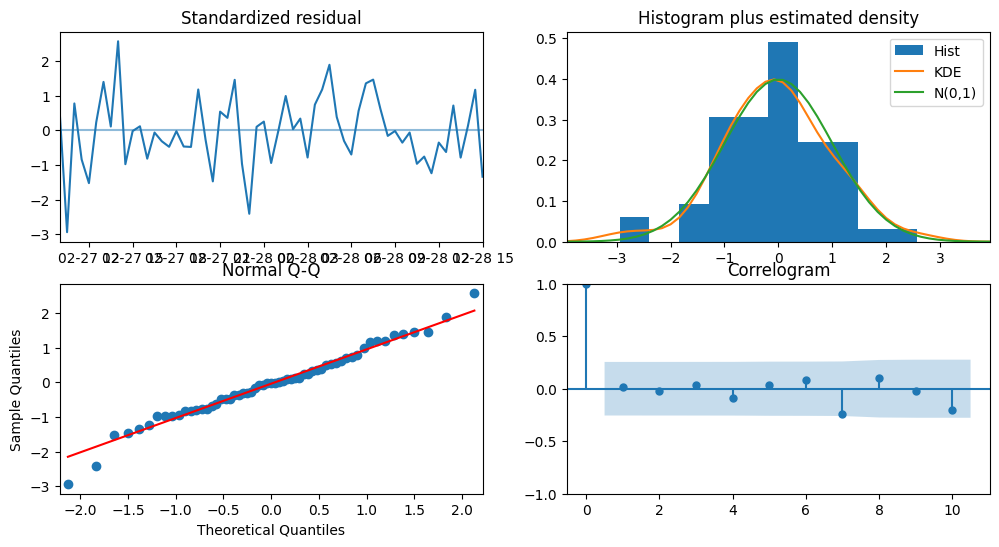

In [239]:
model.plot_diagnostics(figsize=(12,6))
plt.show()


In [240]:

simple_model = pm.ARIMA(order=(1,0,1), with_intercept=True)
simple_model.fit(train)


n_periods = 12

# Complex model forecast
fc_complex = model.predict(n_periods=n_periods)

# Simple model forecast
fc_simple = simple_model.predict(n_periods=n_periods)
                                 
                                 
actual = test.iloc[:n_periods]

mae_complex = mean_absolute_error(actual, fc_complex)
mae_simple  = mean_absolute_error(actual, fc_simple)

print("Complex ARIMA(2,0,4) MAE:", mae_complex)
print("Simple  ARIMA(1,0,1) MAE:", mae_simple)



Complex ARIMA(2,0,4) MAE: 3.5796922966721305
Simple  ARIMA(1,0,1) MAE: 5.456929272997407


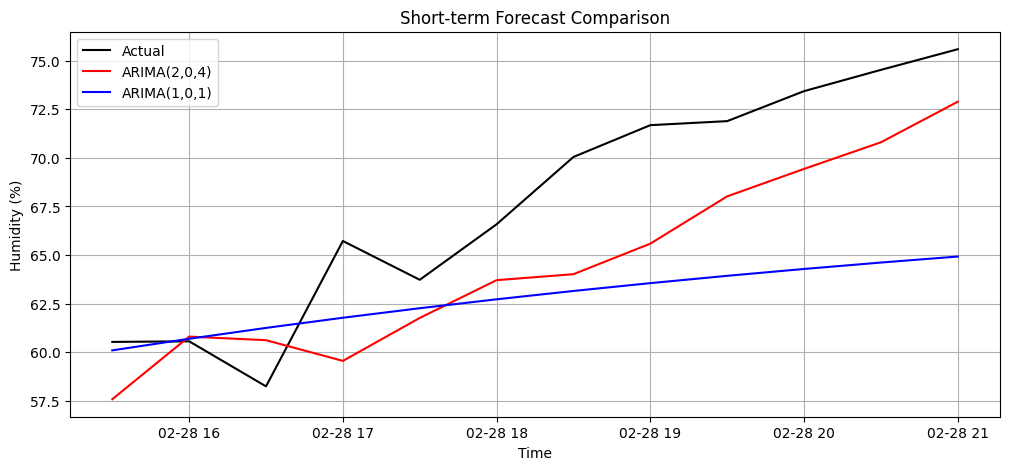

In [241]:

plt.figure(figsize=(12,5))
plt.plot(test.index[:n_periods], actual, label="Actual", color="black")
plt.plot(test.index[:n_periods], fc_complex, label="ARIMA(2,0,4)", color="red")
plt.plot(test.index[:n_periods], fc_simple, label="ARIMA(1,0,1)", color="blue")

plt.title("Short-term Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Humidity (%)")
plt.legend()
plt.grid(True)
plt.show()
